<!-- formatted -->
## Recap

- Previously, we covered **what RAG is** and the basic parts of a RAG workflow.
- We also did a quick implementation of all the parts and ran our first RAG application.

Now let's focus on **retrieval**.

<!-- formatted -->
- Imagine our **embeddings and indexing** are already prepared for us.
- Using these indexes to answer user questions — grounded in our own data — is called **retrieval**.

> We'll look further into what strategies we can use to make our retrieval more efficient and reliable.

<!-- formatted -->
## Step 1: User Query

- In the retrieval process, let's start with the very first step: the **user query**. It's the very beginning of the retrieval process.
- The user comes up with a question — let's see what we can do here to make our answers more reliable and grounded.

<!-- formatted -->
![multi_query.png](multi_query.png)

## Multi-Query

One thing we can do right at this first step is **multi-query**.

- Instead of sending the user's single question straight to our retriever, we use an LLM to **rewrite the question into multiple variations** of itself.
- Each variation is phrased a little differently but is still asking essentially the same thing.
- We run retrieval for **each** of these rewritten queries against our vector store and pool the results together.

> The idea: a single query might not phrase things the same way our documents do, so one embedding search can miss relevant chunks. Multiple phrasings of the same question increase the chance that at least one of them lands close to the right documents in embedding space.

- Once we have results from all the queries, we de-duplicate and combine them into one set of retrieved documents to pass forward.

This is a simple way to make retrieval a bit more robust to however the user happened to phrase their question.

## Let's prepare our indexing first

In [46]:
import os
from operator import itemgetter

from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()

loader = WebBaseLoader(
    web_paths=[
        "https://en.wikipedia.org/wiki/Artificial_intelligence",
        "https://en.wikipedia.org/wiki/Generative_AI",
        "https://en.wikipedia.org/wiki/Large_Language_Model"
    ]
)

docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150,
)

split_docs = text_splitter.split_documents(docs)

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

embedding_model = OpenAIEmbeddings(
    openai_api_base="https://openrouter.ai/api/v1",
    model="openai/text-embedding-3-large",
    openai_api_key=OPENROUTER_API_KEY
)

# Here the split_docs are first embedded using the model we specified, and then inserted into the vector store.
vector_store = Chroma.from_documents(
    documents=split_docs,
    embedding=embedding_model,
    collection_name="basic-rag-overview-1",
)

# So here we have our data loaded, splited, embedded and indexed in the vector Store(Chroma)
retriever = vector_store.as_retriever()
retriever.invoke("What is LLM?")

[Document(id='4dfd65d7-c7f5-46a3-bb7f-7bc14cfc831f', metadata={'title': 'Large language model - Wikipedia', 'source': 'https://en.wikipedia.org/wiki/Large_Language_Model', 'language': 'en'}, page_content='Agency[edit]\nMain article: AI agent\nAn LLM is typically not an autonomous agent by itself, as it lacks the ability to interact with dynamic environments, recall past behaviors, and plan future actions. But it can be transformed into an agent by adding supporting elements: the role (profile) and the surrounding environment of an agent can be additional inputs to the LLM, while memory can be integrated as a tool or provided as additional input. Instructions and input patterns are used to make the LLM plan actions and tool use is used to potentially carry out these actions.[49]'),
 Document(id='81db7ce2-f3f2-47d8-abab-36834fb80813', metadata={'title': 'Large language model - Wikipedia', 'source': 'https://en.wikipedia.org/wiki/Large_Language_Model', 'language': 'en'}, page_content='Age

## Lets start with tackling MultiQuery

In [27]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    input_variables=["question"],
    template="Rewrite the following question into 3 different variations of itself to give different perspectives to the question: {question}. Provide each question in a separate line and do not include any other text in your response."
)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.8, reasoning_format="hidden")

# This breaks the user question to 3 different variations of itself to give different perspectives to the question.
generate_question_pipeline = prompt_template | llm | StrOutputParser() | (lambda x: [q.strip() for q in x.splitlines()])

# result = generate_question_pipeline.invoke({"question": "What is LLM?"})


In [29]:


prompt_template_llm = PromptTemplate(
    input_variables=["context", "question"],
    template="""Answer the following question based on the retrieved documents. If the answer is not present in the documents, say 'I don't know'.
        Context: {context}
        Question: {question}
    """
)


def deduplicate_page_content(documents: list[list]) -> list:
    seen_texts = set()
    for docs in documents:
        for doc in docs:
            seen_texts.add(doc.page_content)
    deduplicated_documents = [doc for doc in seen_texts]
    print(f"Deduplicated documents: {deduplicated_documents} \n Total: {len(deduplicated_documents)}")
    return deduplicated_documents


chain = (
        {
            "question": itemgetter("question"),
            "context": itemgetter("question") | generate_question_pipeline | retriever.map() | deduplicate_page_content

        }
        | prompt_template_llm
        | llm
        | StrOutputParser()
)

chain.invoke({"question": "What is LLM?"})



Deduplicated documents: ['Text and software code[edit]\nMain articles: Large language model, AI-assisted software development, and List of AI-assisted software development tools\nSee also: Code completion, Autocomplete, List of large language models, List of text corpora, and List of chatbots\nLarge language models (LLMs) are trained on tokenized text from large corpora and are capable of natural language processing, machine translation, and natural language generation.[53]', 'Ein Large Language Model (kurz LLM, englisch), übertragen großes Sprachmodell, ist die softwaretechnische Realisierung eines mathematischen Sprachmodells, das sich durch seine Fähigkeit zur Textgenerierung auszeichnet.[1][2] Es handelt sich um ein sogenanntes computerlinguistisches Wahrscheinlichkeitsmodell, das statistische Wort- und Satzfolge-Beziehungen aus einer Vielzahl von Textdokumenten durch einen rechenintensiven Trainingsprozess erlernt hat und diese Fähigkeiten seinem Benutzer oder', 'vteLarge language

'A Large Language Model (LLM) is a software implementation of a mathematical language model trained on large text corpora to perform tasks like natural language processing, machine translation, and text generation. It learns statistical relationships between words and sentences through intensive training and uses these patterns to generate coherent text or assist in language-related tasks. The term "LLM" refers to its scale, complexity, and capacity to handle diverse linguistic inputs and outputs. \n\nThis definition is derived from the provided documents, which describe LLMs as models trained on tokenized text, capable of natural language processing, and emphasizing their role in computational linguistics and text generation.'

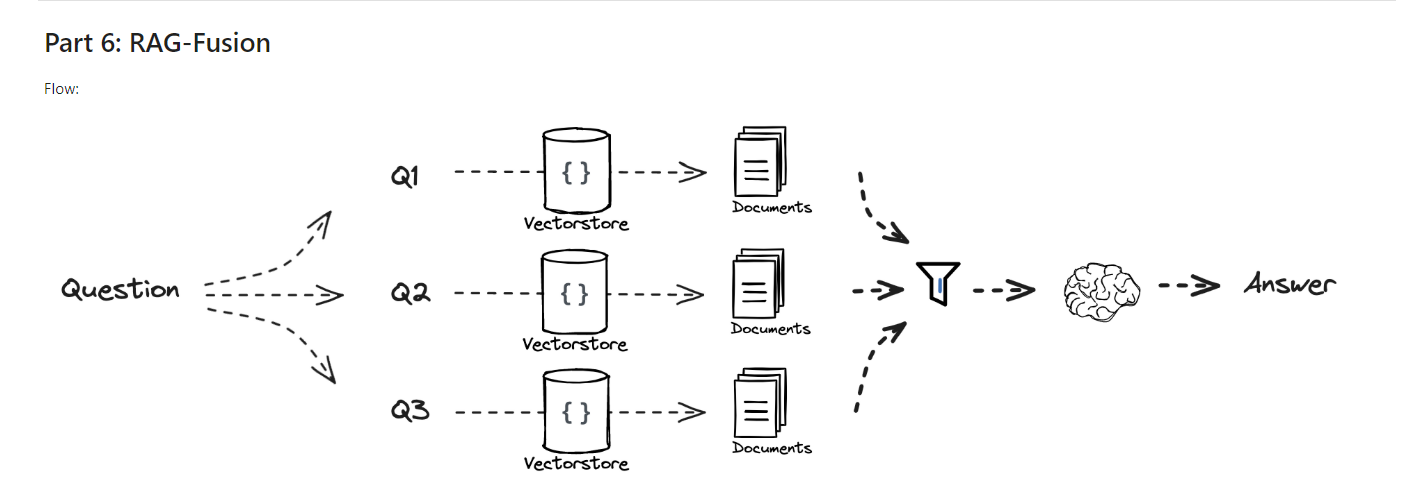
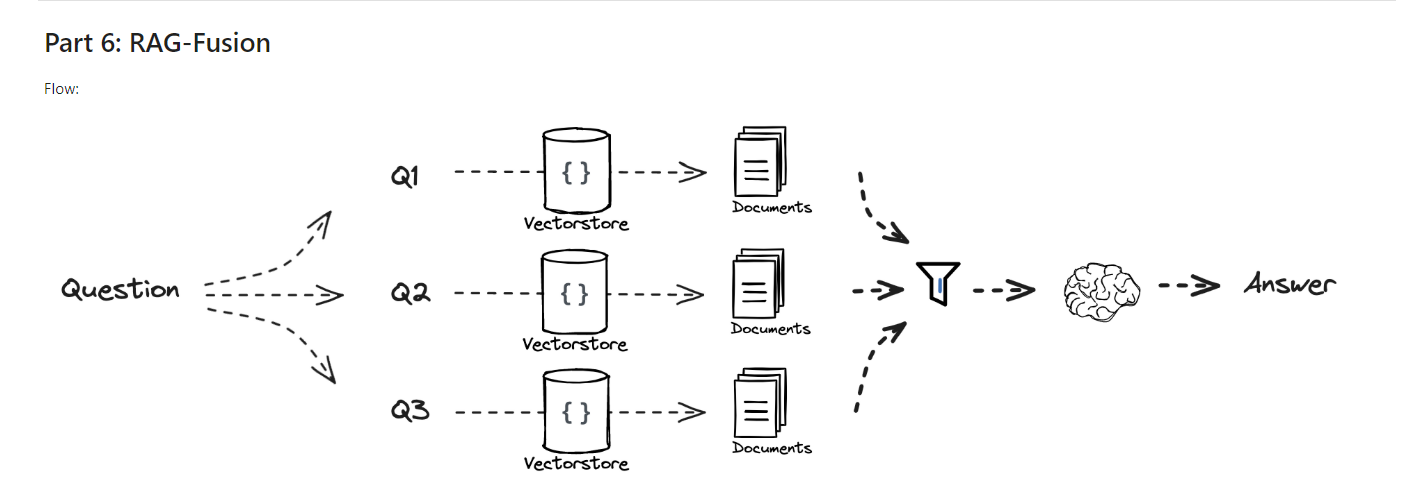

RAG fusion is kind of extension of the multi query. Here also we make multiple questions out of one question then retrieve documents from the vector store , then ranks retrieved documents to keep the most relevant ones. These top-ranked documents are then used by the AI to generate a better answer.

So large part of the RAG fusion will be same as Multiquery, we will replace our method deduplicate_page_content with something like rank_and_select_top_k_documents which will rank the documents and select top k documents to pass to the llm for answer generation and ofcourse also deduplicate.

## Let's implement RAG Fusion

In [20]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    input_variables=["question"],
    template=""" You are an expert at generating search queries for a Retrieval-Augmented Generation (RAG) system.

Given a user's question, generate 5 diverse search queries that capture different ways someone might ask the same question.

Guidelines:
- Preserve the original intent.
- Use different wording, synonyms, and technical terms where appropriate.
- Cover different perspectives or aspects of the question.
- Keep each query concise and suitable for semantic or keyword search.
- Do not answer the question.
- Do not include explanations or numbering.
- Return only the queries, one per line.

Question:
{question}"""
)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.8, reasoning_format="hidden")

# This breaks the user question to 3 different variations of itself to give different perspectives to the question.
generate_question_pipeline = prompt_template | llm | StrOutputParser() | (lambda x: [q.strip() for q in x.splitlines()])

generate_question_pipeline.invoke({"question": "What the various model training techniques??"})

['different model training techniques',
 'types of machine learning training methods',
 'various approaches to training neural networks',
 'supervised versus unsupervised training strategies',
 'common model training algorithms and practices']

In [21]:
prompt_template_llm = PromptTemplate(
    input_variables=["context", "question"],
    template="""Answer the following question based on the retrieved documents. If the answer is not present in the documents, say 'I don't know'.
        Context: {context}
        Question: {question}
    """
)


def reciprocal_rank_fusion(documents: list[list]) -> str:
    """
    Ranks the retrieved documents based on their relevance to the question using Reciprocal Rank Fusion (RRF) and returns the top k documents.
    """
    k = 60

    scores = {}
    for docs in documents:
        for rank, doc in enumerate(docs):
            if doc.page_content not in scores:
                scores[doc.page_content] = 0
            scores[doc.page_content] += 1 / (k + rank + 1)

    # So here we have dictionary with page content and there respective score.
    # Now we will sort the dictionary based on the score and return the top k documents.
    sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    final = "\n\n".join([content for content, _ in sorted_docs])

    print(final)
    return final


chain = (
        {
            "question": itemgetter("question"),
            "context": itemgetter("question") | generate_question_pipeline | retriever.map() | reciprocal_rank_fusion

        }
        | prompt_template_llm
        | llm
        | StrOutputParser()
)

result = chain.invoke({"question": "Explain me how LLM works?"})
print(result)

Category:Large language models

LLMs are typically based on transformer architecture.[3] Generative pre-trained transformers (GPTs) are a type of LLM that is pre-trained to predict the next word.[4] GPTs are then often fine-tuned to follow instructions and to behave as assistants.[5]
Benchmark evaluations for LLMs attempt to measure model reasoning, factual accuracy, alignment, and safety.[6]
History[edit]
The number of publications about large language models by year grouped by publication types
The training compute of notable large models in FLOPs vs publication date over the period 2010–2024. For overall notable models (top left), frontier models (top right), top language models (bottom left) and top models within leading companies (bottom right). The majority of these models are language models.

Instruction fine-tuning is a form of supervised learning used to teach LLMs to follow user instructions. In 2022, OpenAI demonstrated InstructGPT, a version of GPT-3 similarly fine-tuned t

## Decomposition

- Decomposition is a technique where we break down a complex question into smaller, more manageable sub-questions.
- Each sub-question is then answered individually, and the answers are combined to form a final response
There are two variants of this technique
- Answer recursively:
    - In this approach, we break down the question into sub-questions and answer each sub-question recursively. The answers to the sub-questions are then combined to form the final answer.
- Answer in parallel:
    - In this approach, we break down the question into sub-questions and answer each sub-question in parallel. The answers to the sub-questions are then combined to form the final answer.

## Answer Recursively

![decomposition_answer_recursively.png](decomposition_answer_recursively.png)

In [35]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    input_variables=["question"],
    template=""" You are an expert in decomposing a given question into smaller, more manageable sub-questions.
    Each sub-question should be designed in such a way that answering it will contribute to answering the original question.
    Each question can be individually answered.
    Return ONLY the questions, one per line.
    Max 3 questions.



    Question:
    {question}
    """
)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.8, reasoning_format="hidden")

# This breaks the user question to 3 different variations of itself to give different perspectives to the question.
generate_question_pipeline = itemgetter("question") | prompt_template | llm | StrOutputParser() | (
    lambda x: [q.strip() for q in x.splitlines()])

In [52]:

questions = generate_question_pipeline.invoke({"question": "Explain me how LLM works?"})


recursive_prompt = """Here is the question you need to answer:

    \n --- \n {question} \n --- \n

    Here is any available background question + answer pairs:

    \n --- \n {question_answers_pair} \n --- \n

    Here is additional context relevant to the question:

    \n --- \n {context} \n --- \n

    Use the above context and any background question + answer pairs to answer the question: \n {question}
    """

recursive_prompt_template = PromptTemplate.from_template(recursive_prompt)

question_answer_pair = ""
answer = ""

print(questions[0])

# ch = itemgetter("question") | retriever | (lambda x: "\n\n".join([doc.page_content for doc in x]))
#
# ch.invoke({"question": questions[0]})

chain = (
    {
        "question": itemgetter("question"),
        "context": itemgetter("question") | retriever | (lambda x: "\n\n".join([doc.page_content for doc in x])),
        "question_answers_pair": itemgetter("question_answers_pair")
    }
    | recursive_prompt_template
    | llm
    | StrOutputParser()
)


for question in questions:
    answer = chain.invoke({"question": question, "question_answers_pair": question_answer_pair})
    question_answer_pair += f"Question: {question}\nAnswer: {answer}\n----------\n"


print (f"Final Answer: {answer}\n --------------------- \n")

print (f"Question Answer Pair: {question_answer_pair}")



What are the main components and architecture of a large language model?
Final Answer: **Generating a response with a trained LLM is an autoregressive loop that turns a user prompt into a sequence of tokens, one token at a time.**  
The steps below show what happens inside the model, how the next‑token distribution is formed, and which sampling strategies can be used to turn that distribution into actual text.

---

## 1. From prompt to model input

| Step | What is done | Why it matters |
|------|--------------|----------------|
| **1.1 Tokenization** | The raw prompt is passed through the same tokenizer (BPE/WordPiece, etc.) that was used during training, producing a list of token IDs `x = [t₁, t₂ … tₙ]`. | Guarantees the model sees the exact same discrete symbols it learned on. |
| **1.2 Add special tokens** | For chat‑style models a `<bos>` (begin‑of‑sentence), `<system>`, `<assistant>` or similar markers are prepended/appended. | Provides the model with context about the role of e